In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import h5py, os
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

from emcee import EnsembleSampler
from trianglechain import TriangleChain

from msi.gaussian_mixture.likemdn import LikeMDN
from msfm.utils import prior, parameters

# network predictions

In [35]:
def load_preds(base_dir, model_dir, n_steps=None, file_label=None):
    out_dir = os.path.join(base_dir, model_dir)
    
    if n_steps is None:
        preds_file = os.path.join(out_dir, f"preds.h5")
    elif file_label is None:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")
    else:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}_{file_label}.h5")

    with h5py.File(preds_file, "r") as f:
        # fiducial
        fidu_train_preds = f["fiducial/train/pred"][:]
        fidu_vali_preds = f["fiducial/vali/pred"][:]

        print(f"fidu_train_preds =   {fidu_train_preds.shape}")
        print(f"fidu_vali_preds =    {fidu_vali_preds.shape}")

        # grid
        grid_preds = f["grid/pred"][:]
        grid_cosmos = f["grid/cosmo"][:]
        grid_sobol = f["grid/i_sobol"][:]
        print(f"grid_preds.shape =   {grid_preds.shape}")
        print(f"grid_cosmos.shape =  {grid_cosmos.shape}")
        print(f"grid_sobol.shape =   {grid_cosmos.shape}")

    return fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol

### choose a run

In [36]:
# base_dir = "/pscratch/sd/a/athomsen/run_files/v3"
base_dir = "/Users/arne/data/DESY3/models/v3/"

In [37]:
# # clustering only
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

In [38]:
# # clustering only, with and without survey systematics
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# # without survey systematics
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
    
# print(no_survey_systematics_fidu_vali_preds.shape)


In [39]:
# lensing only
model_dir = "2023-05-29_09-55-49_resnet_vanilla"
n_steps = 50000

param_labels = ["Om", "s8", "Aia", "n_Aia"]
param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$']
fiducial_point = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5}

fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

fidu_train_preds =   (750, 4)
fidu_vali_preds =    (50, 4)
grid_preds.shape =   (2499, 16, 4)
grid_cosmos.shape =  (2499, 4)
grid_sobol.shape =   (2499, 4)


In [40]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000

# param_labels = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

In [41]:
n_params = len(param_labels)
assert n_params == fidu_train_preds.shape[-1] == grid_preds.shape[-1]

obs_pred = np.median(fidu_vali_preds, axis=0)

# Gaussian mixture model

In [42]:
preds = np.concatenate(grid_preds, axis=0)
thetas = np.repeat(grid_cosmos, preds.shape[0]//grid_cosmos.shape[0], axis=0)

print(preds.shape)
print(thetas.shape)

(39984, 4)
(39984, 4)


In [72]:
# p(summary | theta)
model = LikeMDN(
    # theta
    nx=thetas.shape[1],
    # summary
    ny=preds.shape[1],
    filename_checkpoint=None,
    n_gaussians=4,
    u_units=256,
    n_layers=3,
    activation="relu",
    input_noise_sig=0.0,
)

23-06-29 11:49:56   likemdn.py WAR   Before self.build_model() 


23-06-29 11:49:57   likemdn.py INF   created MDN model with n_params=214076 
Model: "likemdn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise_9 (Gaussian  (None, 4)                 0         
 Noise)                                                          
                                                                 
 dense_45 (Dense)            (None, 256)               1280      
                                                                 
 dropout_36 (Dropout)        (None, 256)               0         
                                                                 
 dense_46 (Dense)            (None, 256)               65792     
                                                                 
 dropout_37 (Dropout)        (None, 256)               0         
                                                                 
 dense_47 (Dense)            (None, 256)        

In [70]:
# split_index = -2

# summary_train = np.concatenate(grid_preds[:,:split_index,:], axis=0)
# theta_train = np.repeat(grid_cosmos, summary_train.shape[0]//grid_cosmos.shape[0], axis=0)

# print(summary_train.shape)
# print(theta_train.shape)

# summary_vali = np.concatenate(grid_preds[:,split_index:,:], axis=0)
# theta_vali = np.repeat(grid_cosmos, summary_vali.shape[0]//grid_cosmos.shape[0], axis=0)

# print(summary_vali.shape)
# print(theta_vali.shape)

# # p(summary | theta)
# model = LikeMDN(
#     # theta
#     nx=theta_train.shape[1],
#     # summary
#     ny=summary_train.shape[1],
#     filename_checkpoint=None,
#     n_gaussians=4,
#     u_units=256,
#     n_layers=3,
#     learning_rate=0.001,
#     activation="relu",
#     input_noise_sig=0.0,
# )

# history = model.fit(
#     x=theta_train,
#     y=summary_train,
#     epochs=300,
#     batch_size=4096,
#     verb=2
# )

In [74]:
history = model.fit(
    x=thetas,
    y=preds,
    epochs=1000,
    batch_size=2499,
    verb=2
)

23-06-29 11:50:07   likemdn.py INF   wrote None_scalers.pkl 
23-06-29 11:50:07   likemdn.py INF   fitting with 1000 epoch with 12 steps 
23-06-29 11:50:07   likemdn.py INF   input_noise_sig=0.0 
Epoch 1/1000
12/12 - 2s - loss: 3.7411 - val_loss: 3.4142 - 2s/epoch - 179ms/step
Epoch 2/1000
12/12 - 1s - loss: 3.1848 - val_loss: 2.8657 - 1s/epoch - 103ms/step
Epoch 3/1000
12/12 - 1s - loss: 2.5546 - val_loss: 2.2191 - 990ms/epoch - 83ms/step
Epoch 4/1000
12/12 - 1s - loss: 1.9106 - val_loss: 1.6057 - 941ms/epoch - 78ms/step
Epoch 5/1000
12/12 - 1s - loss: 1.3655 - val_loss: 1.1325 - 900ms/epoch - 75ms/step
Epoch 6/1000
12/12 - 1s - loss: 0.9795 - val_loss: 0.8331 - 927ms/epoch - 77ms/step
Epoch 7/1000
12/12 - 1s - loss: 0.6761 - val_loss: 0.6242 - 855ms/epoch - 71ms/step
Epoch 8/1000
12/12 - 1s - loss: 0.4245 - val_loss: 0.3145 - 922ms/epoch - 77ms/step
Epoch 9/1000
12/12 - 1s - loss: 0.1891 - val_loss: 0.1067 - 906ms/epoch - 75ms/step
Epoch 10/1000
12/12 - 1s - loss: 0.0544 - val_loss: -

KeyboardInterrupt: 

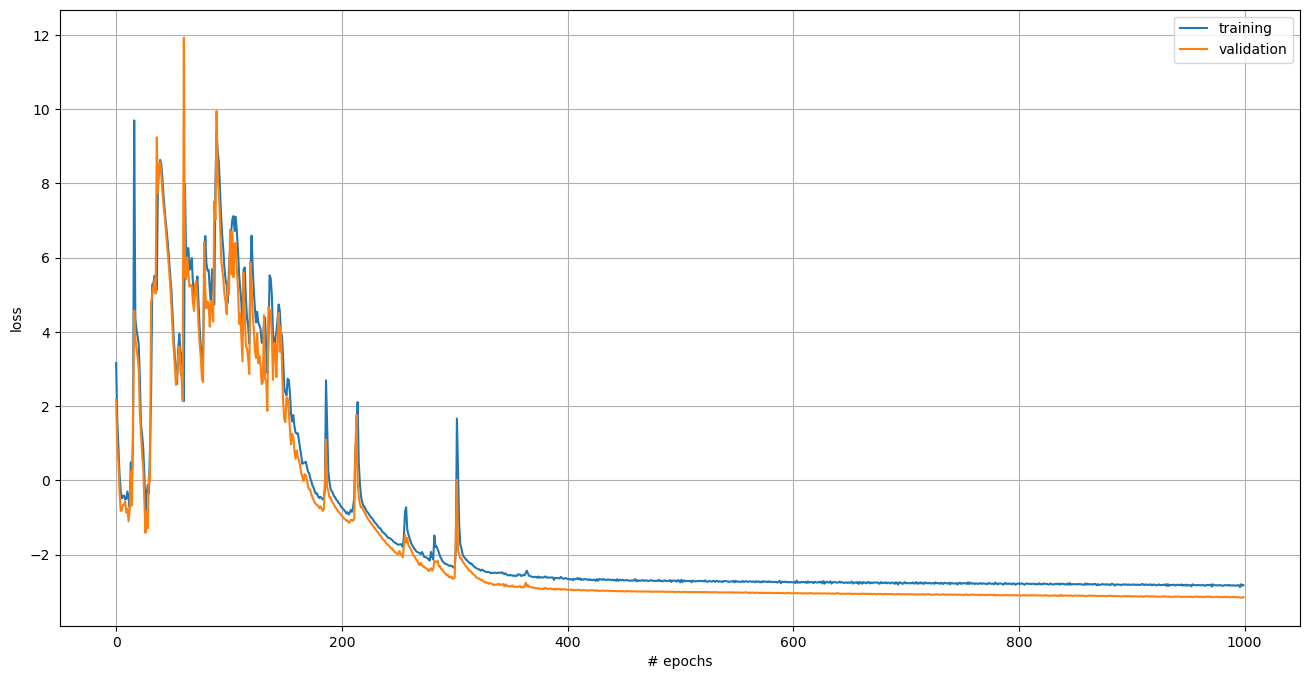

In [46]:
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(history.history["loss"], label="training")
ax.plot(history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear")
ax.grid(True)

# MCMC

In [64]:
tf_pred = tf.cast(obs_pred, dtype=tf.float32)
tf_pred = tf.expand_dims(tf_pred, axis=0)

def log_posterior(X): 
    # evaluate the normal distribution
    log_prob = model.log_like(X, tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=param_labels, conf=None)

    return log_prob

In [65]:
# emcee setup
np.random.seed(42)

nwalkers = 1024
p0 = np.random.normal(loc=parameters.get_fiducials(param_labels), scale=1e-3, size=(nwalkers, n_params))
print("Initial values in prior: ", np.all(prior.in_grid_prior(p0, params=param_labels))) 

Initial values in prior:  True


In [66]:
# sample burn in
sampler = EnsembleSampler(nwalkers, n_params, log_posterior, vectorize=True)
state = sampler.run_mcmc(p0, 100)
sampler.reset()

# run the actual chain
sampler.run_mcmc(state, 1000, progress=True)

# save the result
chain = sampler.get_chain(flat=True)
# np.save(os.path.join(base_dir, model_dir, f"chain_{n_steps}_normal.npy"), chain)

100%|██████████| 1000/1000 [02:38<00:00,  6.29it/s]


# plot

### compare GP ABC to normalizing flow

100%|██████████| 6/6 [00:00<00:00, 1273.83it/s]


(<Figure size 1600x1600 with 16 Axes>,
 array([[<Axes: ylabel='$\\Omega_m$'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='$\\sigma_8$'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='$A_{IA}$'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: xlabel='$\\Omega_m$', ylabel='$\\eta_{A_{IA}}$'>,
         <Axes: xlabel='$\\sigma_8$'>, <Axes: xlabel='$A_{IA}$'>,
         <Axes: xlabel='$\\eta_{A_{IA}}$'>]], dtype=object))

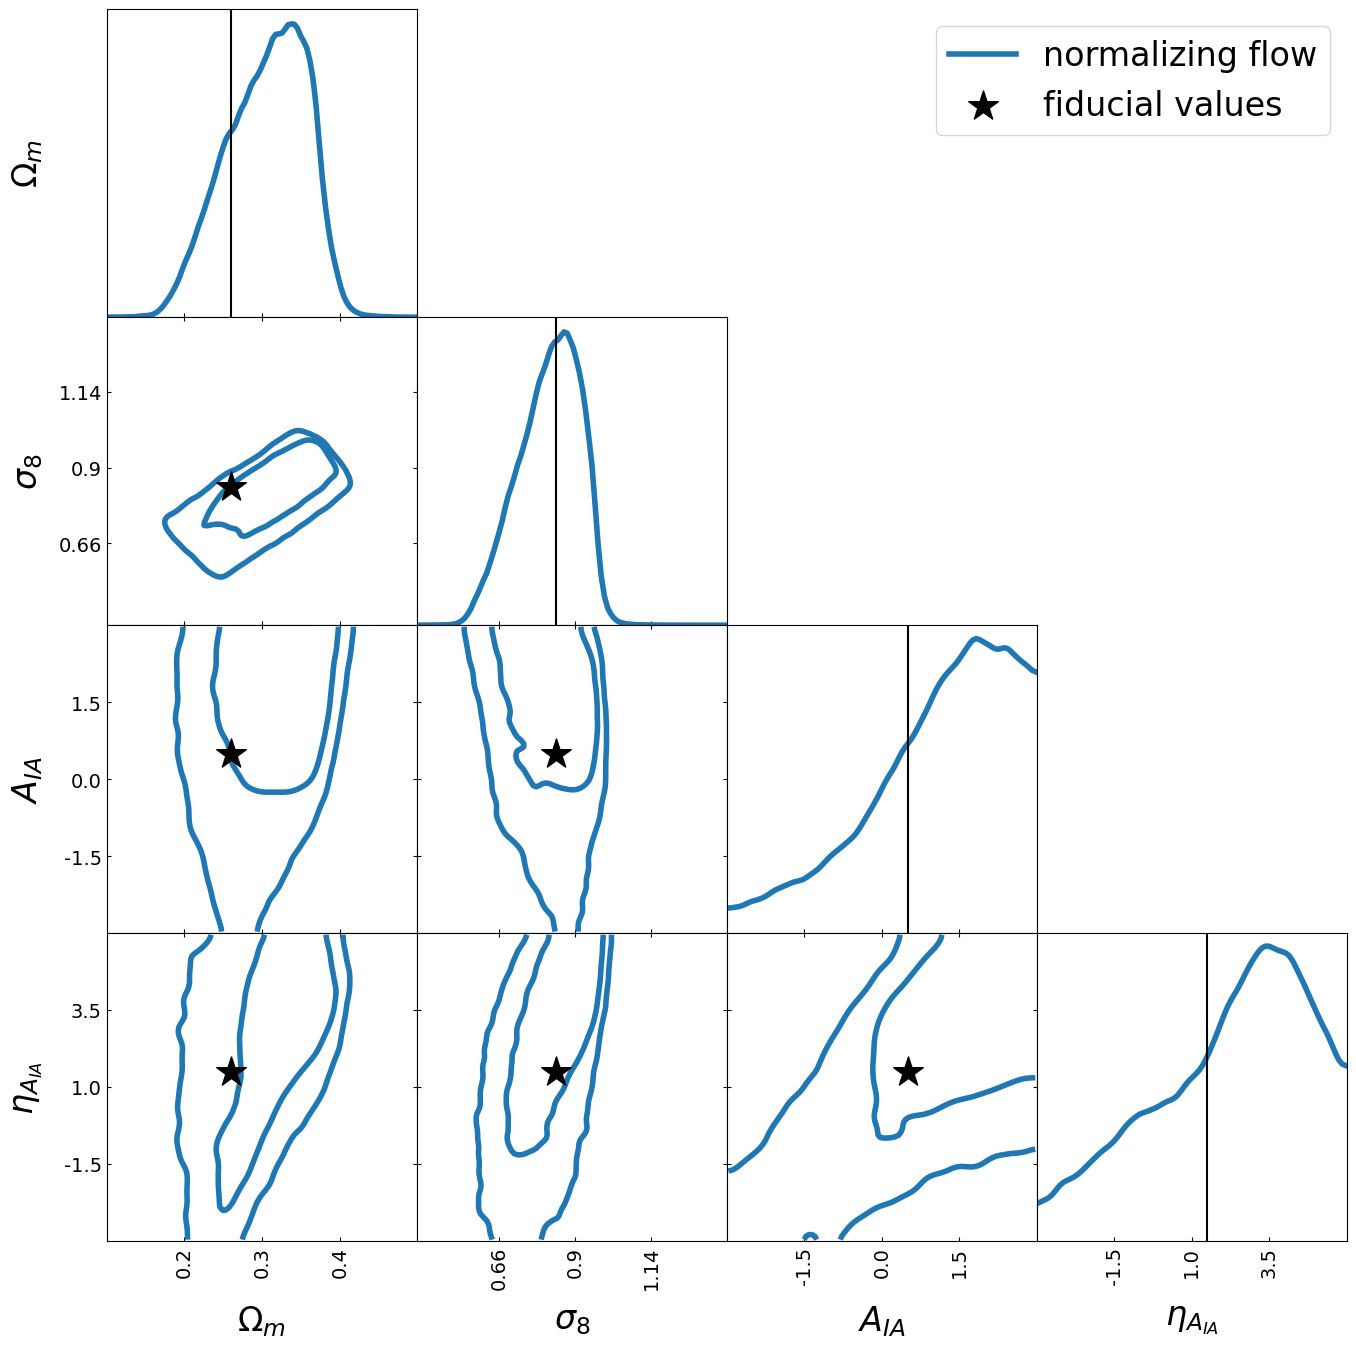

In [67]:
tri = TriangleChain(labels=param_latex, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})

# Gaussian likelihood
tri.contour_cl(chain, names=param_labels, label="normalizing flow")

# fiducial
tri.scatter(
    fiducial_point,
    label="fiducial values",
    plot_histograms_1D=False,
    color="k",
    show_legend=True,
    scatter_vline_1D=True,
)
# tri.fig.savefig(os.path.join(base_dir, model_dir, f"contours_{n_steps}_normal.png"), bbox_inches="tight", dpi=300)